In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print('ok')

ok


In [2]:
prix = pd.Series([100,102, 99, 105], index = ['lun', 'mar', 'mer', 'jeu'])
print(prix['mar'])
print(prix.mean())

df = pd.DataFrame({
    'Apple': [150, 152, 149, 155],
    'Google': [2800, 2790, 2810, 2850],
}, index=['lun', 'mar', 'mer', 'jeu'])
df

102
101.5


,Apple,Google
lun,150,2800
mar,152,2790
mer,149,2810
jeu,155,2850


In [3]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
data = yf.download(tickers, start='2022-01-01', end='2024-12-31')['Close']
data.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2022-01-03,177.939682,170.404495,143.717133,322.462341
2022-01-04,175.681396,167.522003,143.130325,316.933105
2022-01-05,171.008270,164.356995,136.564056,304.766632
2022-01-06,168.153549,163.253998,136.536819,302.358459
2022-01-07,168.319748,162.554001,135.812698,302.512573


In [4]:
print(data.shape)
print(data.index.min(), "->", data.index.max())

(752, 4)
2022-01-03 00:00:00 -> 2024-12-30 00:00:00


In [6]:
rendements = data.pct_change().dropna()
rendements.head()

Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2022-01-04,-0.012691,-0.016916,-0.004083,-0.017147
2022-01-05,-0.026600,-0.018893,-0.045876,-0.038388
2022-01-06,-0.016693,-0.006711,-0.000199,-0.007902
2022-01-07,0.000988,-0.004288,-0.005303,0.000510
2022-01-10,0.000116,-0.006570,0.012061,0.000732


In [7]:
rendements_moyens = rendements.mean()
print("Rendement quotidien moyen: ")
print(rendements_moyens)

matrice_cov = rendements.cov()
print("\nMatrice de covariance ")
matrice_cov

Rendement quotidien moyen: 
Ticker
AAPL     0.000601
AMZN     0.000640
GOOGL    0.000586
MSFT     0.000502
dtype: float64

Matrice de covariance 


Ticker,AAPL,AMZN,GOOGL,MSFT
Ticker,,,,
AAPL,0.000292,0.000232,0.000219,0.000203
AMZN,0.000232,0.000584,0.000324,0.000289
GOOGL,0.000219,0.000324,0.000426,0.000249
MSFT,0.000203,0.000289,0.000249,0.000302


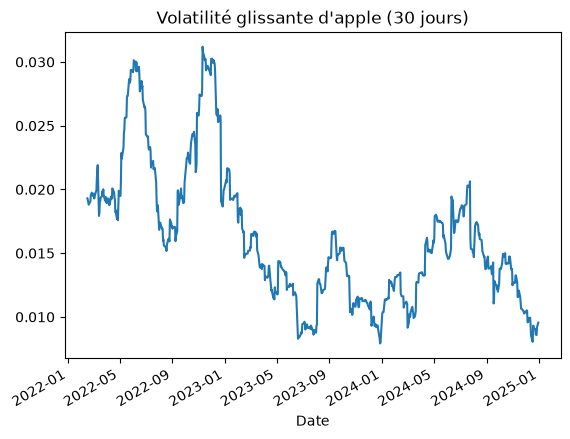

In [9]:
volatilite_glissante = rendements['AAPL'].rolling(window=30).std()
volatilite_glissante.plot(title="Volatilité glissante d'apple (30 jours)")
plt.show()